In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression

# 1. Reduce Overfitting

Original Feature - Train MSE: 280.367, Test MSE: 446.553
Discretized Feature - Train MSE: 339.937, Test MSE: 475.515


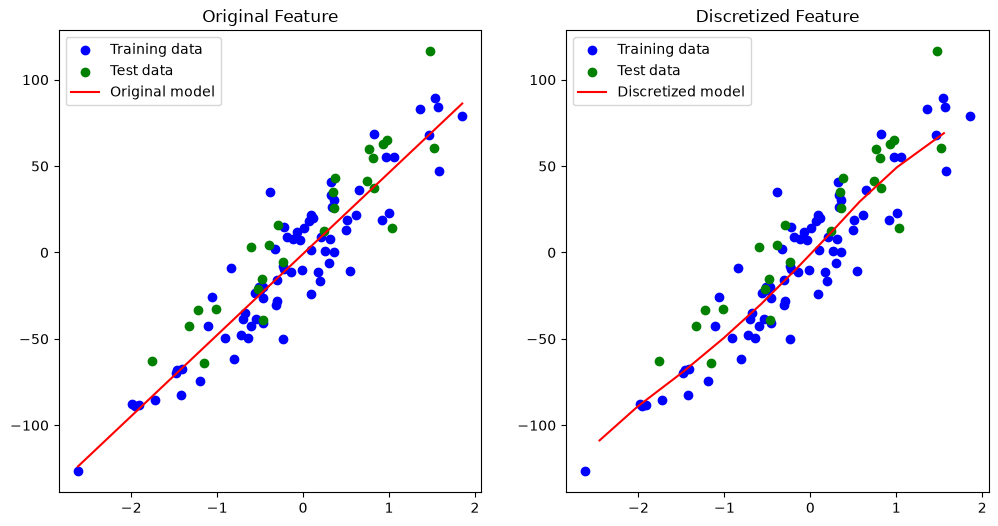

In [3]:
# Generate synthetic data
X, y = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Linear regression with the original feature
model_original = LinearRegression()
model_original.fit(X_train, y_train)
y_train_pred_orig = model_original.predict(X_train)
y_test_pred_orig = model_original.predict(X_test)

# Discretize the feature
disc = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='kmeans')
X_train_disc = disc.fit_transform(X_train)
X_test_disc = disc.transform(X_test)

# Linear regression with the discretized feature
model_disc = LinearRegression()
model_disc.fit(X_train_disc, y_train)
y_train_pred_disc = model_disc.predict(X_train_disc)
y_test_pred_disc = model_disc.predict(X_test_disc)

# Calculate and print MSE for both models
mse_train_orig = mean_squared_error(y_train, y_train_pred_orig)
mse_test_orig = mean_squared_error(y_test, y_test_pred_orig)
mse_train_disc = mean_squared_error(y_train, y_train_pred_disc)
mse_test_disc = mean_squared_error(y_test, y_test_pred_disc)

print(f'Original Feature - Train MSE: {mse_train_orig:.3f}, Test MSE: {mse_test_orig:.3f}')
print(f'Discretized Feature - Train MSE: {mse_train_disc:.3f}, Test MSE: {mse_test_disc:.3f}')

# Plotting to visualize overfitting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='green', label='Test data')
plt.plot(np.sort(X_train, axis=0), model_original.predict(np.sort(X_train, axis=0)), color='red', label='Original model')
plt.title('Original Feature')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='green', label='Test data')
# For discretized model, predictions are plotted against the mid-point of each bin
bin_edges = disc.bin_edges_[0]
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.plot(bin_mids, model_disc.predict(disc.transform(bin_mids.reshape(-1, 1))), color='red', label='Discretized model')
plt.title('Discretized Feature')
plt.legend()

plt.show()

# 2. Handle Non Linear Relationships (Approximate)

## Example 1 : In Regression

Shape of X: (100, 1)
Shape of y: (100, 1)


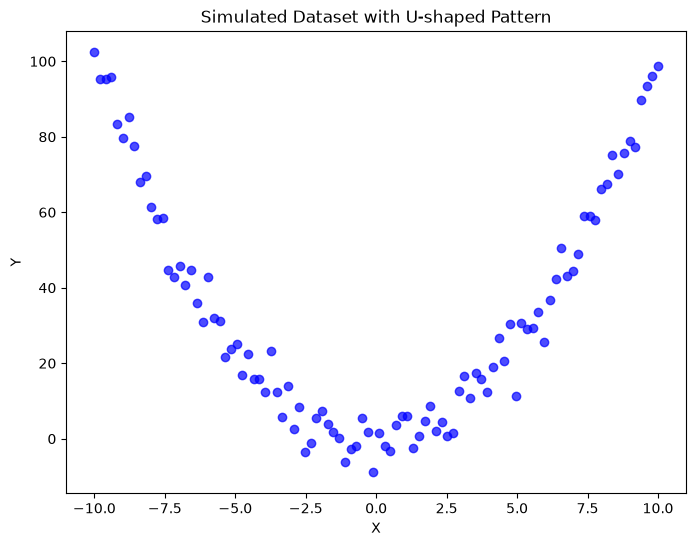

In [4]:
# Ensure consistent environment
np.random.seed(42)

# Generate the dataset
X = np.linspace(-10, 10, 100).reshape(-1, 1)  # X is a 100x1 vector
y = X**2 + np.random.normal(0, 5, size=X.shape[0]).reshape(-1,1)  # y is directly based on X, ensuring matching length

# Verify the shapes
print(f"Shape of X: {X.shape}")  # Should print (100, 1)
print(f"Shape of y: {y.shape}")  # Should print (100,)

# Plotting the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7)
plt.title('Simulated Dataset with U-shaped Pattern')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


In [5]:
# Fit non-discretized linear regression
model_nd = LinearRegression().fit(X, y)
y_pred_nd = model_nd.predict(X)

In [6]:
# Fit discretized linear regression
discretizer = KBinsDiscretizer(n_bins=4, encode='onehot', strategy='quantile')
X_discrete = discretizer.fit_transform(X)

model_d = LinearRegression().fit(X_discrete, y)

X_discrete.toarray()

c:\Users\avanindra Bose\ML Tips\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],


In [7]:
# Generate predictions for the original X values using the discretized model
y_pred_d = model_d.predict(X_discrete)

# Calculate MSE for both models using the correct set of predictions
mse_nd = mean_squared_error(y, y_pred_nd)  # No change needed here
mse_d = mean_squared_error(y, y_pred_d)  # Use corrected predictions

(mse_nd, mse_d)

(962.2105319929109, 314.458204161572)

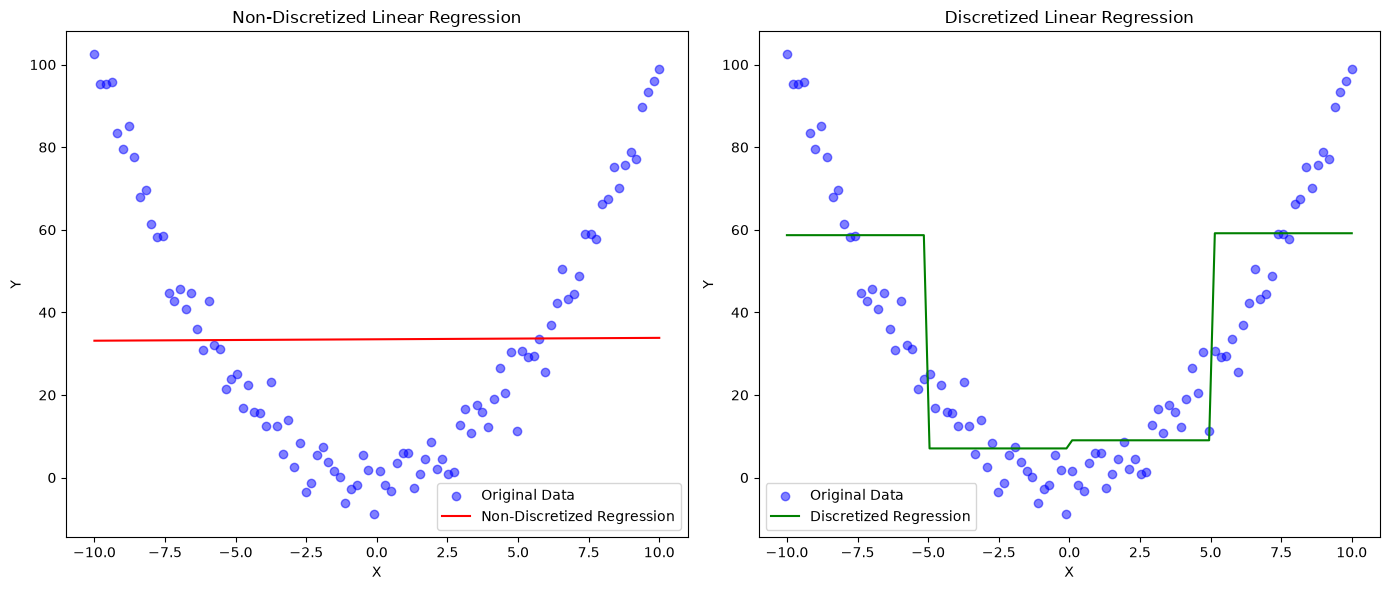

In [8]:
# Plot the results
plt.figure(figsize=(14, 6))

# Non-discretized regression
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', alpha=0.5, label='Original Data')
plt.plot(X, y_pred_nd, color='red', label='Non-Discretized Regression')
plt.title('Non-Discretized Linear Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

# Discretized regression
plt.subplot(1, 2, 2)
plt.scatter(X, y, color='blue', alpha=0.5, label='Original Data')
plt.plot(X, y_pred_d, color='green', label='Discretized Regression')
plt.title('Discretized Linear Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

## Example 2 : Classification Problem

In [11]:
# Generate a 2D toy dataset with a non-linear decision boundary
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model 1: Logistic Regression on original features
lr = LogisticRegression()
lr.fit(X_train, y_train)
preds = lr.predict(X_test)
accuracy_original = accuracy_score(y_test, preds)

# Discretization of the features
discretizer = KBinsDiscretizer(n_bins=10, encode='onehot', strategy='quantile')
X_train_binned = discretizer.fit_transform(X_train)
X_test_binned = discretizer.transform(X_test)

# Model 2: Logistic Regression on discretized features
lr_binned = LogisticRegression()
lr_binned.fit(X_train_binned, y_train)
preds_binned = lr_binned.predict(X_test_binned)
accuracy_binned = accuracy_score(y_test, preds_binned)

accuracy_original, accuracy_binned

c:\Users\avanindra Bose\ML Tips\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


(0.8766666666666667, 0.9566666666666667)

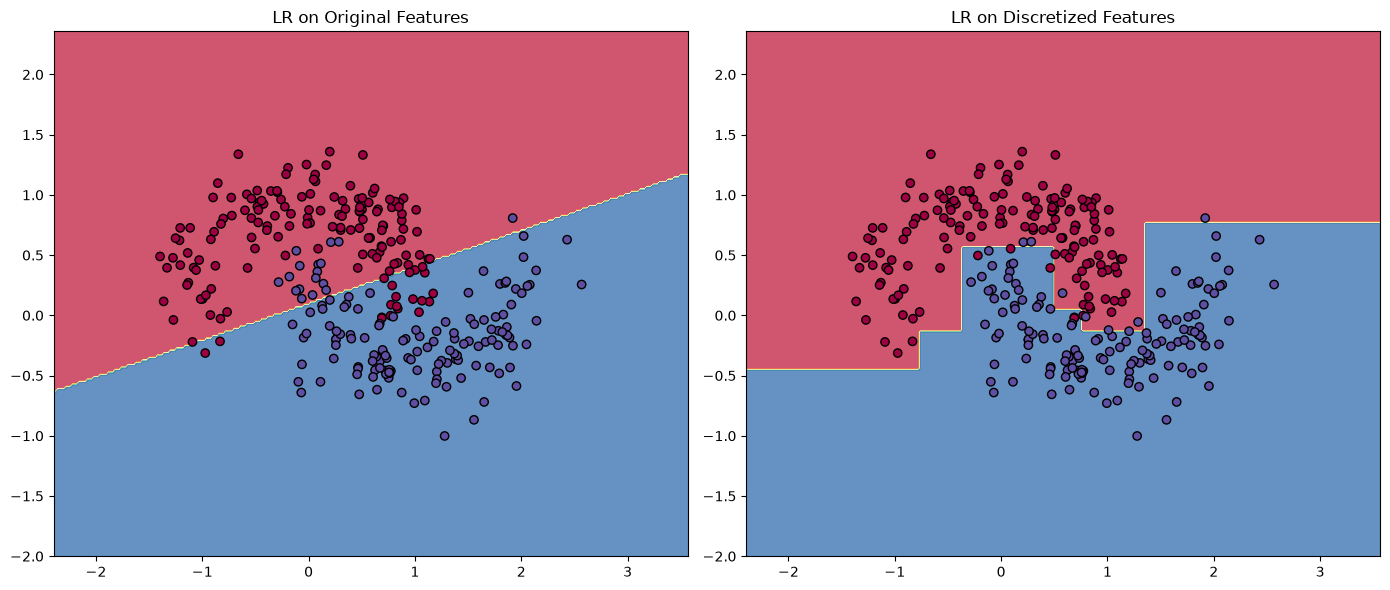

In [12]:
def plot_decision_boundary(model, X, y, ax, title="Decision Boundary", is_discretized=False, discretizer=None):
    # Create a mesh to plot in
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.02  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Preprocess mesh grid if model is trained on discretized features
    if is_discretized and discretizer:
        Z = model.predict(discretizer.transform(np.c_[xx.ravel(), yy.ravel()]))
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

    # Plot also the training points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Spectral)
    ax.set_title(title)
    ax.grid(False)

# Create figure for plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot decision boundary for the original logistic regression model
plot_decision_boundary(lr, X_test, y_test, axs[0], "LR on Original Features")

# Plot decision boundary for the logistic regression model trained on discretized features
plot_decision_boundary(lr_binned, X_test, y_test, axs[1], "LR on Discretized Features", is_discretized=True, discretizer=discretizer)

plt.tight_layout()
plt.show()